# XAUUSD M5 - Data Import & EDA

**Data source:** Dukascopy m5 OHLCV, originally fetched with the use of dukascopy-node app (credits to https://github.com/Leo4815162342) and my ETL pipeline (https://github.com/ady7ady7/cross-market-etl-pipeline) and then stored in DigitalOcean PostgreSQL

**Coverage:** 2021-01-03 - 2026-07-19 (1700+ days, 5+ years of data, 391k+ 5-minute candles in total)

**Note on volume:** Dukascopy volume is tick volume (quote count), not real traded size. Spot XAUUSD has no centralized exchange, so true volume is unavailable. Volume here is a proxy for quoting activity.

The first step is to establish connection with my database, which contains all market data fetched through Dukascopy-node app*. 

(NOT RELEVANT FOR THIS ANALYSIS)
*I've built a pipeline to import and save market data in any DB - please feel free to check the etl-cross-market-pipeline repo on my GitHub if you're interested.

## The Goal

The goal is to check whether there are any features that can be used for predicting the direction of a given session.

For now the most appropriate hypothesis would be:

There are features that have predictive power over the session direction.

In [1]:
import pandas as pd
from sqlalchemy import create_engine
from dotenv import load_dotenv
import os

#also added other imports that I needed here
import seaborn as sns
import matplotlib.pyplot as plt

load_dotenv()

engine = create_engine(
    f"postgresql+psycopg2://{os.getenv('DB_USER')}:{os.getenv('DB_PASSWORD')}"
    f"@{os.getenv('DB_HOST')}:{os.getenv('DB_PORT', 5432)}/{os.getenv('DB_NAME')}"
)

After establishing connection it's time to simply fetch market data.
I also do some basic SQL operations at this point to prepare data:

- get the time in the et_time (America Eastern Time), since it's the timezone that's the most relevant for Gold
- extract the day of the week also in the ET
- do the timestamp ordering

It's also the time to have a first look at my data.

In [2]:
query = """
SELECT
    timestamp AT TIME ZONE 'America/New_York' AS et_time,
    open, 
    high, 
    low, 
    close, 
    volume,
    EXTRACT(DOW FROM timestamp AT TIME ZONE 'America/New_York') AS day_of_week,
    (timestamp AT TIME ZONE 'America/New_York')::date AS trade_date
FROM xauusd_m5_tradfi_ohlcv
ORDER BY timestamp
"""

df = pd.read_sql(query, engine)
df.head()

,et_time,open,high,low,close,volume,day_of_week,trade_date
0,2021-01-03 17:00:00,1904.998,1910.898,1903.288,1908.850,0.68,0.0,2021-01-03
1,2021-01-03 17:05:00,1908.878,1909.258,1907.618,1908.568,0.46,0.0,2021-01-03
2,2021-01-03 17:10:00,1908.518,1909.405,1907.665,1908.805,0.21,0.0,2021-01-03
3,2021-01-03 17:15:00,1908.785,1909.678,1907.978,1909.358,0.09,0.0,2021-01-03
4,2021-01-03 17:20:00,1909.368,1910.588,1909.005,1909.048,0.14,0.0,2021-01-03


In [ ]:
print(f"Shape: {df.shape}")
df['day_of_week'] = df['day_of_week'].astype(int)
df['trade_date'] = pd.to_datetime(df['trade_date'])

print(df.dtypes)

print(f"Date range: {df['et_time'].min()} - {df['et_time'].max()}")
print(f"Unique trade dates: {df['trade_date'].nunique()}")

print(f"Null counts: {df.isnull().sum()}")


Shape: (391955, 8)
et_time        datetime64[us]
open                  float64
high                  float64
low                   float64
close                 float64
volume                float64
day_of_week             int64
trade_date      datetime64[s]
dtype: object

Date range: 2021-01-03 17:00:00 - 2026-07-19 17:55:00
Unique trade dates: 1723
Null counts: et_time        0
open           0
high           0
low            0
close          0
volume         0
day_of_week    0
trade_date     0
dtype: int64


Now this is somewhat expected, as market data was initially gathered through Dukascopy, which is one of the most prominent financial brokers - it's licensed and well known on the market.

However, we also have to keep in mind that volume data they offer is not real market data, but only their platform(s) data, and it's very important. Basically it means that volume analysis is not the right choice in this case, as it's not tied to the real market volume.

There aren't any nulls, but perhaps we're missing some days or candles - maybe they're simply not there - they wouldn't appear as NULL.

In [4]:
expected_bars = pd.date_range(
    start=df['et_time'].min(),
    end=df['et_time'].max(),
    freq='5min'
)
missing_bars = expected_bars.difference(df['et_time'])
print(f"Expected 5-min bars: {len(expected_bars)}")
print(f"Actual bars: {len(df)}")
print(f"Missing bars: {len(missing_bars)}")

Expected 5-min bars: 582636
Actual bars: 391955
Missing bars: 190681


As we can see, about 32.7% of the candles are missing.

However, we must also be aware of the fact that financial markets run only from late Sunday until Friday, and that there are also holidays, when the markets are closed. With that in mind we can move on to do some more robust check, and look which days have the most missing bars.


In [5]:
missing_df = pd.DataFrame({'et_time': missing_bars})
missing_df['day_of_week'] = missing_df['et_time'].dt.dayofweek  # 0=Mon, 6=Sun

print("Missing bars by day of week:")
print(missing_df['day_of_week'].value_counts().sort_index())

weekday_missing = missing_df[missing_df['day_of_week'] < 5].copy()
weekday_missing['hour'] = weekday_missing['et_time'].dt.hour

print("Missing weekday bars by hour:")
print(weekday_missing['hour'].value_counts().sort_index())

Missing bars by day of week:
day_of_week
0     5448
1     3911
2     4173
3     5022
4    31564
5    83232
6    57331
Name: count, dtype: int64
Missing weekday bars by hour:
hour
0       228
1       228
2       229
3       228
4       228
5       228
6       228
7       228
8       228
9       229
10      228
11      303
12      486
13      696
14      780
15    10572
16     9302
17     3651
18     3638
19     3636
20     3636
21     3636
22     3636
23     3636
Name: count, dtype: int64


To run a proper check, I will actually install a new library - pandas_market_calendars, which contains the whole trading calendar for every symbol




In [6]:
import pandas_market_calendars as mcal
cal = mcal.get_calendar('CMEGlobex_Gold')

start_date = df['et_time'].min()
end_date = df['et_time'].max()
calendar = cal.schedule(start_date = start_date, end_date = end_date)
print(calendar)



                         market_open              market_close
2021-01-04 2021-01-03 23:00:00+00:00 2021-01-04 22:00:00+00:00
2021-01-05 2021-01-04 23:00:00+00:00 2021-01-05 22:00:00+00:00
2021-01-06 2021-01-05 23:00:00+00:00 2021-01-06 22:00:00+00:00
2021-01-07 2021-01-06 23:00:00+00:00 2021-01-07 22:00:00+00:00
2021-01-08 2021-01-07 23:00:00+00:00 2021-01-08 22:00:00+00:00
...                              ...                       ...
2026-07-13 2026-07-12 22:00:00+00:00 2026-07-13 21:00:00+00:00
2026-07-14 2026-07-13 22:00:00+00:00 2026-07-14 21:00:00+00:00
2026-07-15 2026-07-14 22:00:00+00:00 2026-07-15 21:00:00+00:00
2026-07-16 2026-07-15 22:00:00+00:00 2026-07-16 21:00:00+00:00
2026-07-17 2026-07-16 22:00:00+00:00 2026-07-17 21:00:00+00:00

[1430 rows x 2 columns]


Now we have a proper list of trading days without all the holidays and weekends, and we can properly calculate the expected bars and then check if there are any missing ones in a proper way.

Gold trades Sun 18:00 ET through Fri 17:00 ET. This means Sunday bars appear in the dataset as a separate `trade_date`, but they logically belong to the Monday session. We drop Sunday bars to align with the CME calendar (Mon–Fri trading days only).


In [7]:
type(calendar)
#it's a pandas DF

df = df[df['et_time'].dt.dayofweek != 6].copy()
print(f"Rows after dropping Sundays: {len(df)}")
print(f"Unique trade_dates: {df['trade_date'].nunique()}")



Rows after dropping Sundays: 366042
Unique trade_dates: 1437


So now there are 1430 days in our calendar vs 1437 days in the dataframe - it's close enough as long as the dates align.

In [8]:
calendar_et = calendar.copy()
calendar_et['market_open'] = calendar['market_open'].dt.tz_convert('America/New_York').dt.tz_localize(None)
calendar_et['market_close'] = calendar['market_close'].dt.tz_convert('America/New_York').dt.tz_localize(None)

df_dates = set(df['trade_date'].dt.date)
cal_dates = set(calendar_et.index.date)

only_in_df = df_dates - cal_dates
only_in_cal = cal_dates - df_dates

print(f"Days in df but not in calendar: {len(only_in_df)}")
print(sorted(only_in_df))
print(f"\nDays in calendar but not in df: {len(only_in_cal)}")
print(sorted(only_in_cal))


Days in df but not in calendar: 8
[datetime.date(2022, 12, 26), datetime.date(2023, 1, 2), datetime.date(2023, 12, 25), datetime.date(2024, 1, 1), datetime.date(2024, 12, 25), datetime.date(2025, 1, 1), datetime.date(2025, 12, 25), datetime.date(2026, 1, 1)]

Days in calendar but not in df: 1
[datetime.date(2021, 10, 15)]


Data coverage is 99.9% complete, and it's the best time to move forward.

Time to add some additional features to visualize, such as the candle range.

In [9]:


df['candle_range'] = df['high'] - df['low']
df['et_hour'] = df['et_time'].dt.hour
df['et_minute'] = df['et_time'].dt.minute
 
df.head(5)




,et_time,open,high,low,close,volume,day_of_week,trade_date,candle_range,et_hour,et_minute
84,2021-01-04 00:00:00,1921.648,1922.658,1921.448,1922.305,0.20,1,2021-01-04,1.210,0,0
85,2021-01-04 00:05:00,1922.315,1923.605,1921.345,1923.468,0.14,1,2021-01-04,2.260,0,5
86,2021-01-04 00:10:00,1923.485,1923.818,1922.585,1922.745,0.21,1,2021-01-04,1.233,0,10
87,2021-01-04 00:15:00,1922.755,1923.835,1922.635,1923.835,0.16,1,2021-01-04,1.200,0,15
88,2021-01-04 00:20:00,1923.865,1925.475,1923.668,1925.335,0.45,1,2021-01-04,1.807,0,20


Time to do a mock price overview on some chosen period to test if everything looks fine.

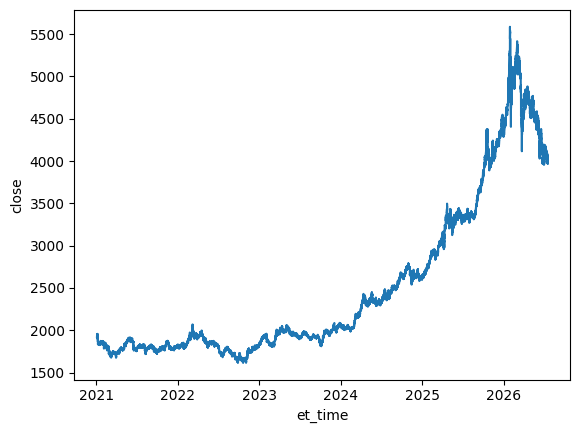

In [10]:
close_prices_df = df[['et_time', 'close']].copy()


line_chart = sns.lineplot(
    close_prices_df,
    x = 'et_time',
    y = 'close'
)

plt.show()

Everything looks fine, there are no visible gaps and the price represents the actual GOLD prices, which were checked on the online charts.

I've also done a few more individual checks for 10 random candles, and all the prices matched.
This manual step is very important to identify the potential issues early.

With a candle range added for each 5-minute candle, it's possible to explore how these ranges differ with a boxplot.

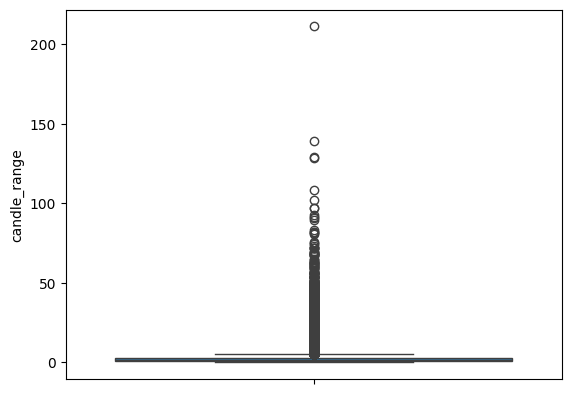

In [11]:
candles_range_df = df[['et_time', 'candle_range']].copy()

boxplot = sns.boxplot(
    candles_range_df['candle_range']
)

plt.show()

The current approach doesn't show anything clearly, as there is a lot of outliers, which could be the candles appearing mostly during high-impact market news or unexpected world events.

The IQR and median are very close to 0 on this chart, and yet I'm unable to make any meaningful observations with the current scale.

Perhaps it would be better to aggregate the candles in bigger buckets, like 30-minute ones, to make clearer observations.

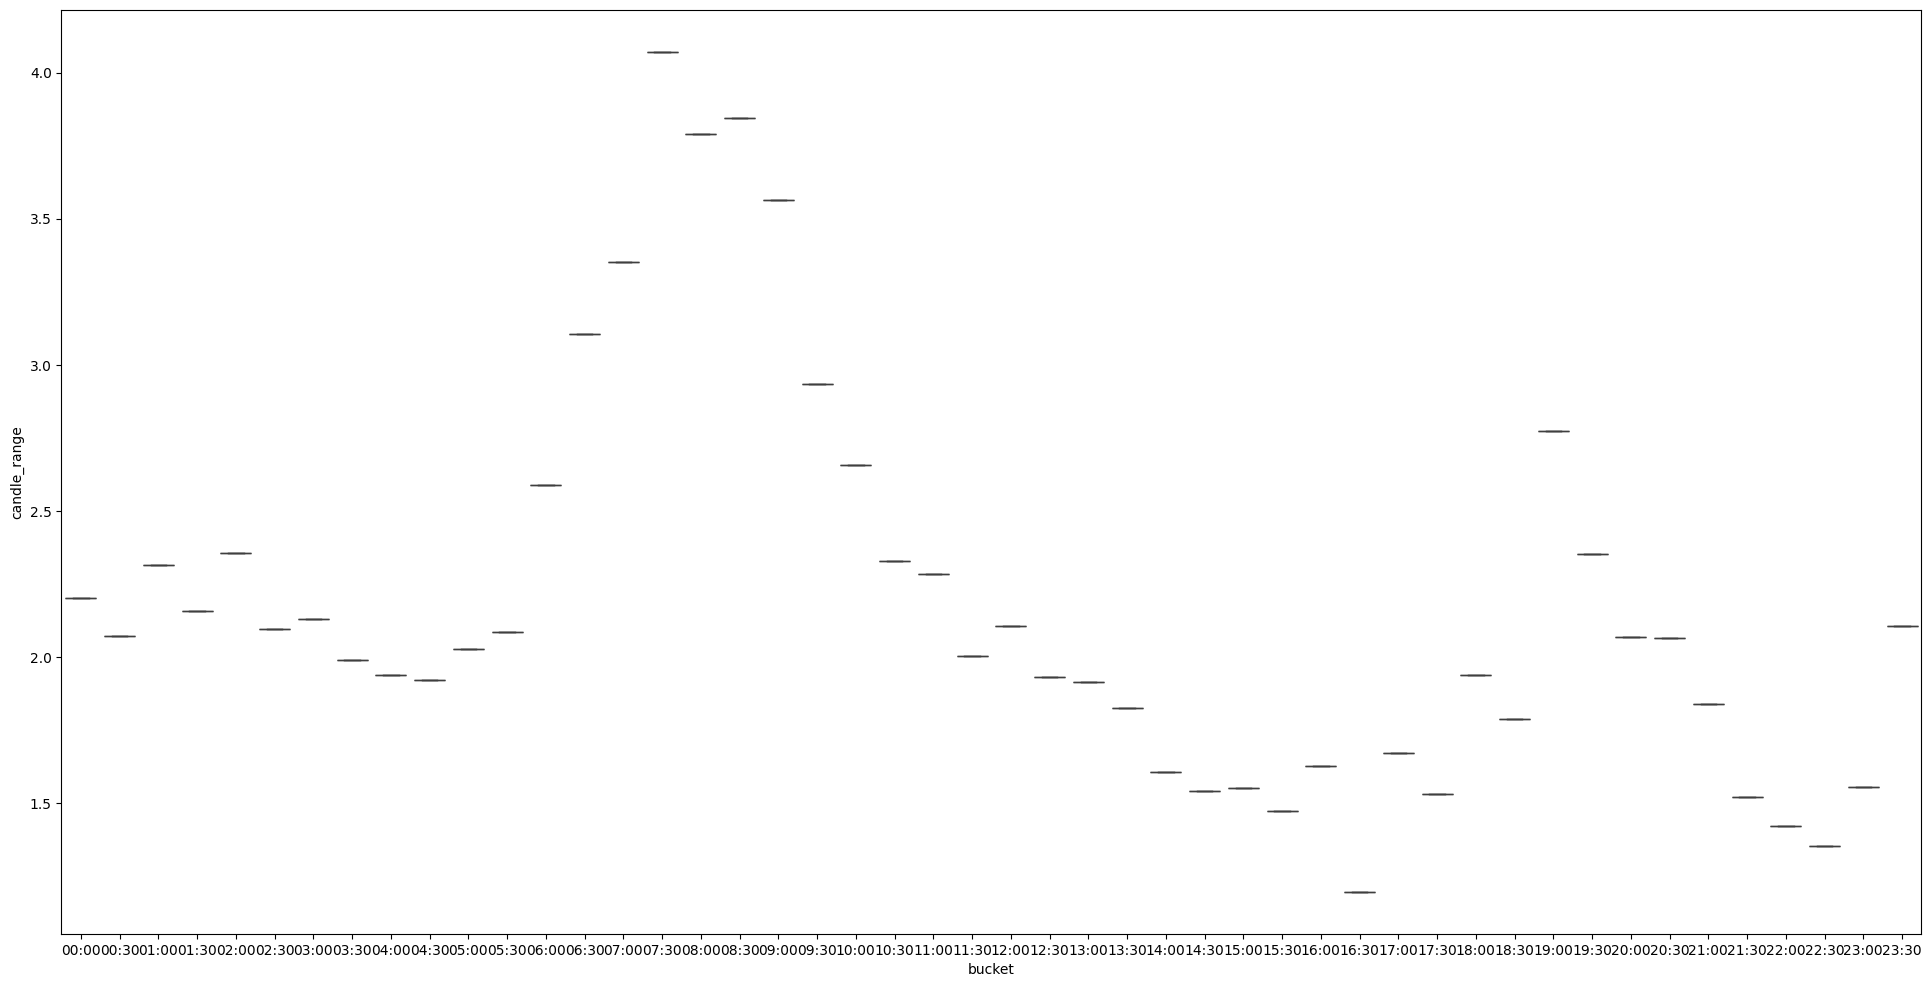

In [12]:
df.head(5)
df['bucket'] = df['et_time'].dt.floor('30min').dt.strftime('%H:%M')


plt.figure(figsize = (24, 12))
df_bucket_df = df.groupby('bucket')['candle_range'].mean().reset_index()
boxplot = sns.boxplot(
    df_bucket_df,
    x = 'bucket',
    y = 'candle_range'
)
plt.show()


With this huge figure size we're able to clearly see that there seem to be meaningful differences in terms of average candle ranges in different time buckets.

This image is still a bit unclear, as there's truly a lot of buckets, so perhaps it would make sense to show these ordered in a table.

Also it might make sense to verify statistically if the differences are truly meaningful or just random noise.

In [13]:

df_bucket_df= df_bucket_df.sort_values(by = 'candle_range', ascending = False)
df_bucket_df.head(15)

,bucket,candle_range
15,07:30,4.071128
17,08:30,3.844618
16,08:00,3.791308
18,09:00,3.563067
14,07:00,3.351293
13,06:30,3.104027
19,09:30,2.932764
38,19:00,2.773176
20,10:00,2.657464
12,06:00,2.590258


This table gives a clear indication that the highest candles of the day are during the 6:30 - 10:30 (as 10:00 bucket ends at 10:30) ET time, which could help us further investigate this particular daily bucket more thoroughly.

All of the candles from that period are to be found in the top 10 most volatile daily buckets.


I'm also interested whether highs or lows of a days tend to form within the most volatile candle ranges, somewhere around that 6:30-10:30 ET time period.

In [14]:
hod = df.loc[df.groupby('trade_date')['high'].idxmax(), ['trade_date', 'bucket']]
lod = df.loc[df.groupby('trade_date')['low'].idxmin(), ['trade_date', 'bucket']]

print(hod['bucket'].value_counts().head(10))
print(lod['bucket'].value_counts().head(10))

bucket
00:00    113
23:30     93
07:30     86
08:30     67
01:00     59
06:30     59
07:00     55
09:00     55
08:00     54
00:30     51
Name: count, dtype: int64
bucket
00:00    143
07:30     94
08:00     78
08:30     66
06:30     64
23:30     58
01:00     56
09:00     52
01:30     42
00:30     41
Name: count, dtype: int64


While 23:30 - 00:00 seem to be one interesting observation, we can clearly see the candles from the 6:30 onwards again in the most popular high of the day/low of the day candles.

I also came to a conclusion that the project should focus mainly on EU + US session trading hours.
We already found that most highs/lows of the day form between 6-10 ET (around 12-16:00 EU time), so it makes the most sense to look at the European session (3:00 ET onwards) and the overlap with US (9:30 ET-17:00 ET).

I wouldn't be able to use any of the Asia information anyway, so this is a very logical decision.
The only thing to look at in regards to the Asian session is the price gap between 17:00 ET and 3:00 ET next day.


As we filter out the Asian session, the visualizations should also become much clearer.

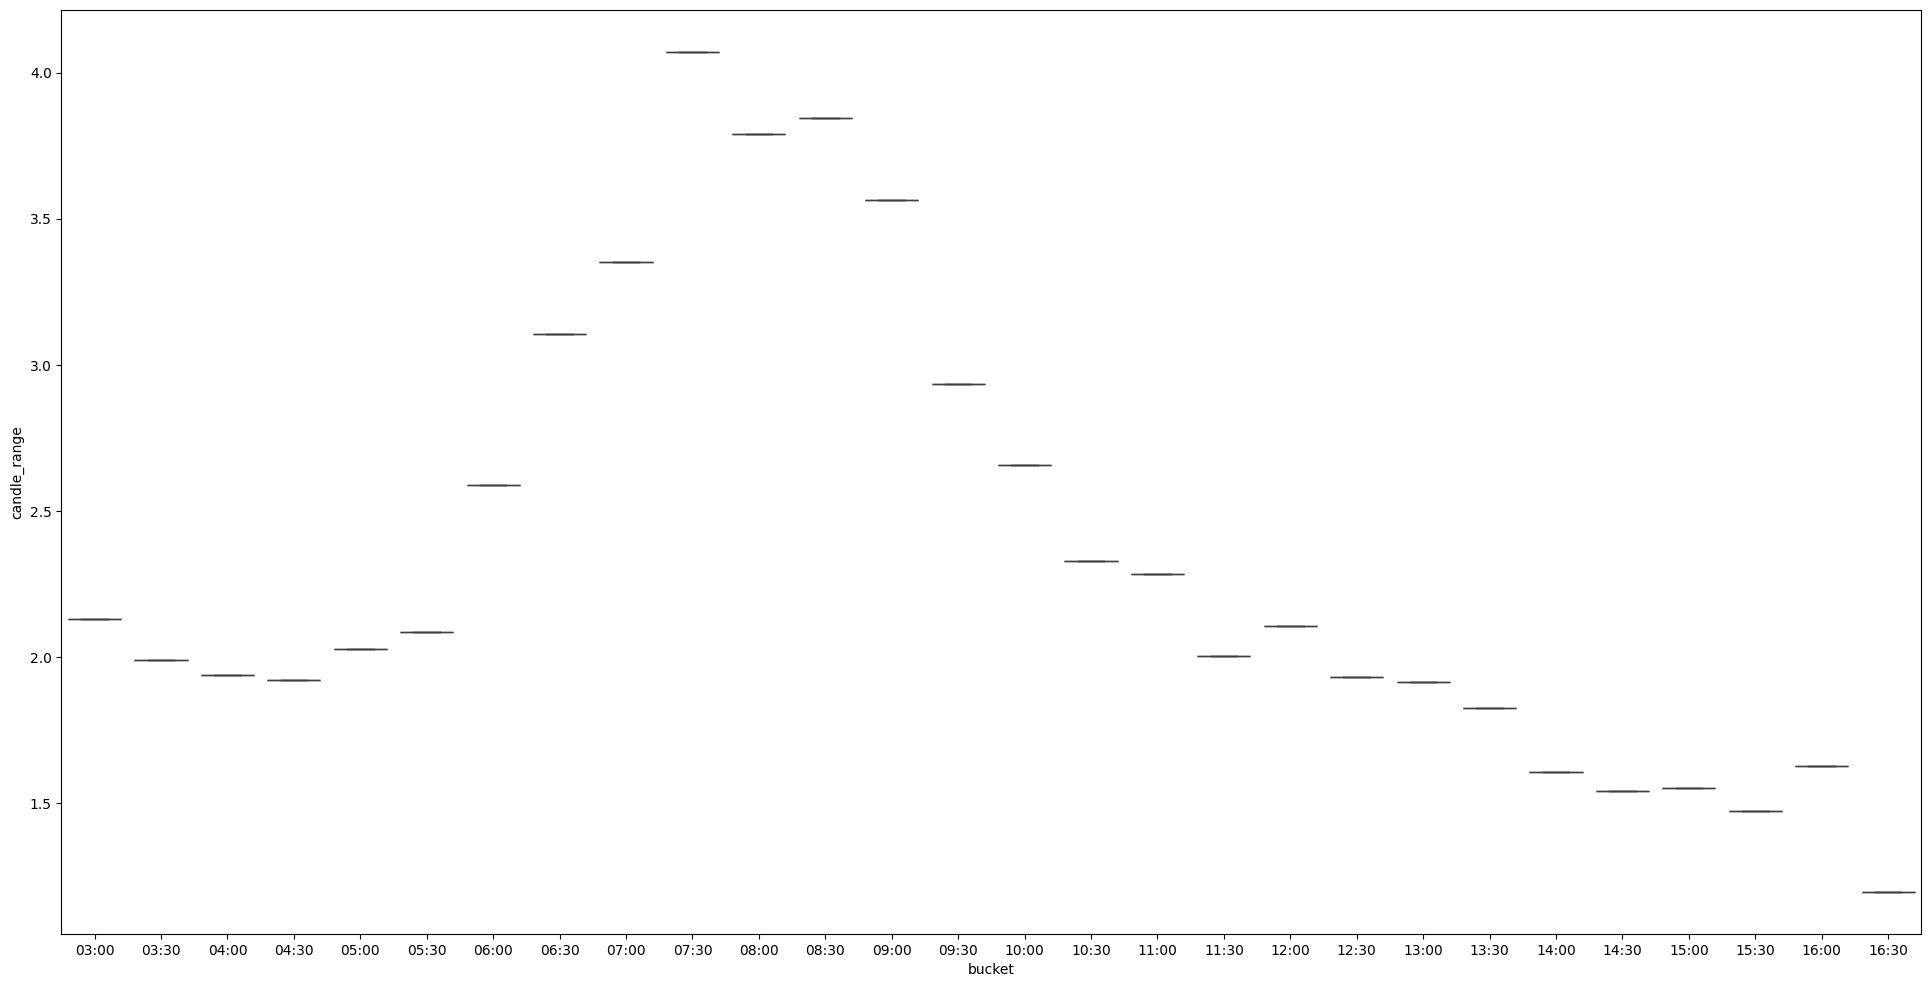

In [15]:
filtered_df = df[(df['et_hour'] >= 3) & (df['et_hour'] <= 16)].copy()
filtered_df['bucket'] = filtered_df['et_time'].dt.floor('30min').dt.strftime('%H:%M')


plt.figure(figsize = (24, 12))
filtered_bucket_df = filtered_df.groupby('bucket')['candle_range'].mean().reset_index()
boxplot = sns.boxplot(
    filtered_bucket_df,
    x = 'bucket',
    y = 'candle_range'
)
plt.show()


Now the time buckets are clearly visible, and it's more obvious there's high volatility between around 6:30-10:30.

With this in mind, I will also take a look at high/low forming buckets, so the time bucket with the lowest/highest price of the day.

In [16]:
hod = filtered_df.loc[filtered_df.groupby('trade_date')['high'].idxmax(), ['trade_date', 'bucket']]
lod = filtered_df.loc[filtered_df.groupby('trade_date')['low'].idxmin(), ['trade_date', 'bucket']]

print(hod['bucket'].value_counts().head(10))
print(lod['bucket'].value_counts().head(10))

bucket
03:00    147
07:30    122
08:30     88
06:30     85
09:00     77
08:00     76
07:00     72
06:00     61
03:30     54
09:30     51
Name: count, dtype: int64
bucket
03:00    136
07:30    123
08:00    101
08:30     93
06:30     92
09:00     80
03:30     63
06:00     61
07:00     60
04:00     51
Name: count, dtype: int64


The highs and lows of the day often form at the London open.

With the data filtered it's time to do some daily candle aggregations and proceed with day by day analysis.
To do that, I will have to mark the sesssion_open and close for each day.

This will also include adding a few new columns:

- gap_size is the difference between the previous session close (16:30 ET) and the current session open (3:00 ET). It's very often analyzed in the financial markets.

- day_bullish checks whether the session close is higher than the session open - 'bullish' in financial market terminology signifies an uptrend, where the prices are going higher, where 'bearish' stands for a downtrend, so the prices going lower.

- day_name - just a display change to the current day of week - I will not be using this for model training anyway, but it will help the human brain to interpret visualized data

- session open/high/low/close prices

In [17]:
filtered_df['day_name'] = filtered_df['et_time'].dt.day_name()

session_open = filtered_df[filtered_df['bucket'] == '03:00'].groupby(['trade_date', 'day_name', 'day_of_week'])['open'].first().reset_index().rename(columns={'open': 'session_open'})
session_close = filtered_df.groupby('trade_date')['close'].last().reset_index().rename(columns={'close': 'session_close'})
session_high = filtered_df.groupby('trade_date')['high'].max().reset_index().rename(columns={'high': 'session_high'})
session_low = filtered_df.groupby('trade_date')['low'].min().reset_index().rename(columns={'low': 'session_low'})

#building the daily aggregation below
daily = session_open.merge(
    session_close, on='trade_date').merge(
        session_low, on = 'trade_date').merge(
            session_high, on = 'trade_date')
        
daily['prev_close'] = daily['session_close'].shift(1)
daily['gap_size'] = daily['session_open'] - daily['prev_close']
daily['day_bullish'] = (daily['session_close'] > daily['session_open']).astype(int)
daily = daily.dropna()
print(daily.shape)
daily.head()

(1425, 10)


,trade_date,day_name,day_of_week,session_open,session_close,session_low,session_high,prev_close,gap_size,day_bullish
1,2021-01-05,Tuesday,2,1942.315,1949.698,1938.938,1952.925,1942.548,-0.233,1
2,2021-01-06,Wednesday,3,1952.795,1917.998,1900.755,1959.225,1949.698,3.097,0
3,2021-01-07,Thursday,4,1918.000,1913.818,1906.705,1921.968,1917.998,0.002,0
4,2021-01-08,Friday,5,1888.905,1848.508,1828.038,1894.445,1913.818,-24.913,0
5,2021-01-11,Monday,1,1849.175,1843.038,1828.968,1852.444,1848.508,0.667,0


Now it's also the best time to introduce gap direction - whether the price has risen between the previous close and the current open.

This will be represented by the 'gap_bullish' column - 1 signifies that the current open price is higher than the previous close price, 0 means the opposite.

This is also the perfect time to illustrate the distribution of the gap sizes and check whether gap direction has any predictive power over the next day's price move direction.

gap_bullish
0    0.489264
1    0.508409
Name: day_bullish, dtype: float64


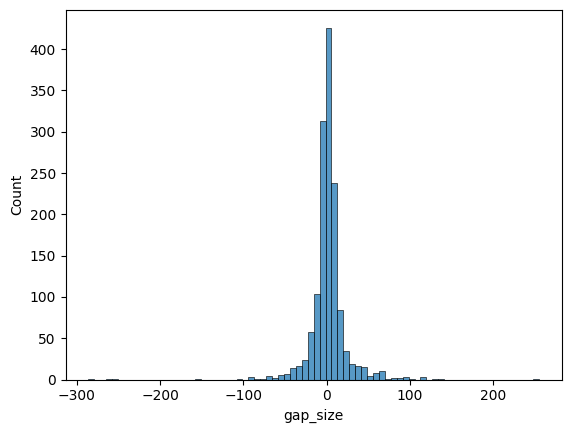

In [18]:
daily['gap_bullish'] = (daily['gap_size'] > 0).astype(int)
print(daily.groupby('gap_bullish')['day_bullish'].mean())

gaps_plot = sns.histplot(
    daily['gap_size'])
plt.show()

The gap distribution looks a bit bell-shaped but it certainly isn't a normal distribution.
It shows right skew with a heavier tail on the positive side. 

This means large overnight gaps to the upside occur a bit more frequently than equivalent downside gaps.

It's also visible that gap direction itself has no predictive power for the next day direction, and for that matter, it should be considered as irrelevant noise rather than signal, at least in isolation.

Perhaps if this information is combined with the day of the week it has more predictive power, and I will proceed to check it.

In [19]:
daily.head()
daily_gaps_agg = daily.groupby(['day_name', 'gap_bullish'])['day_bullish'].agg(
    ['count', 'mean']).reset_index()
daily_gaps_agg = daily_gaps_agg.sort_values(by = 'mean', ascending = False)
daily_gaps_agg.head(15)

,day_name,gap_bullish,count,mean
1,Friday,1,159,0.540881
2,Monday,0,144,0.527778
7,Tuesday,1,163,0.527607
8,Wednesday,0,132,0.522727
5,Thursday,1,157,0.509554
3,Monday,1,139,0.482014
6,Tuesday,0,125,0.480000
9,Wednesday,1,155,0.477419
0,Friday,0,122,0.467213
4,Thursday,0,129,0.441860


Interestingly adding weekdays adds more variety to the results:

Friday with a bullish gap ended as a bullish day about 54% during the analyzed period.
Thursday with a bearish gap ended as a bullish day only about 44% times during the analyzed period.

The difference doesn't seem like much, but it's 10% percent points between two most extreme examples - not bad and perhaps useful later.

At this point, it's a natural choice for me to also see whether daily ranges and daily directions (not including gaps) differ by weekdays.

I'll add the 'daily range' column to measure these more easily.

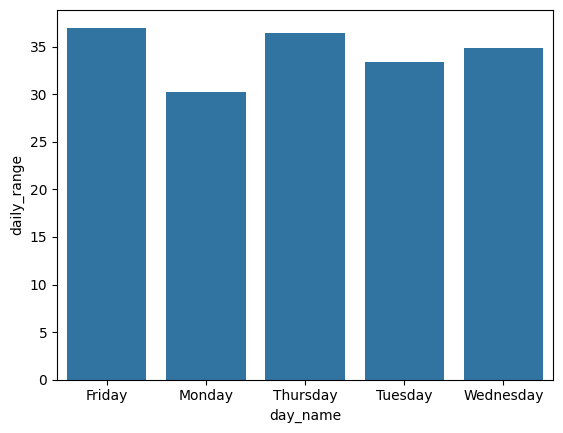

In [20]:
daily['daily_range'] = daily['session_high'] - daily['session_low']
daily.head()

daily_ranges_weekdays_agg = daily.groupby(['day_name'])[['daily_range', 'day_bullish']].mean().reset_index()
daily_ranges_weekdays_agg.head(15)

barplot = sns.barplot(
    daily_ranges_weekdays_agg,
    x = 'day_name',
    y = 'daily_range'
)

plt.show()

No visible differences, with the current approach the days seem to have pretty similar average daily ranges.

What if this is combined with the gap direction?

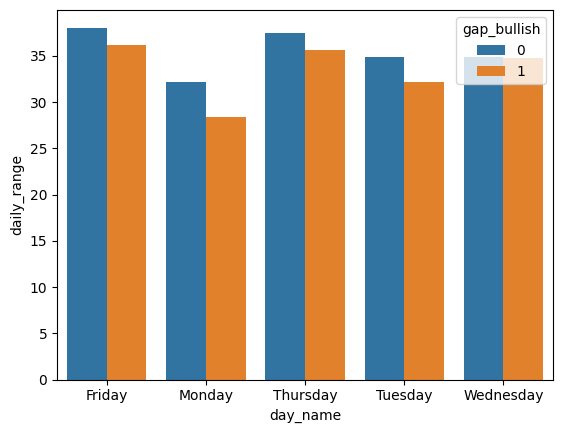

,day_name,gap_bullish,daily_range
0,Friday,0,38.071672
1,Friday,1,36.222956
2,Monday,0,32.145042
3,Monday,1,28.384525
4,Thursday,0,37.496767
5,Thursday,1,35.666446
6,Tuesday,0,34.941816
7,Tuesday,1,32.180239
8,Wednesday,0,34.850167
9,Wednesday,1,34.810626


In [21]:
daily['daily_range'] = daily['session_high'] - daily['session_low']
daily.head()

daily_ranges_weekdays_agg = daily.groupby(['day_name', 'gap_bullish'])['daily_range'].mean().reset_index()
daily_ranges_weekdays_agg.head(15)

barplot = sns.barplot(
    daily_ranges_weekdays_agg,
    x = 'day_name',
    y = 'daily_range',
    hue = 'gap_bullish'
)

plt.show()

daily_ranges_weekdays_agg.head(15)

There are subtle differences, but their magnitude is negligible.
Since the current results do not show any meaningful differences, I should analyze more data.



The next step is to split the London session from the NY session and analyze how these two sesions interact. That would obviously mean that I'd have to leave the prediction window to the NY session in the end.

The features I'm willing to add now are:

- London session range
- London session direction (bullish/bearish)
- NY session afterwards -> does it continue or rather revert the London direction, does it keep the volatility magnitude?

Few facts here:
- The official London physical gold market (LBMA) trades between 8:00 AM - 5:00 PM GMT (3:00-10:00 ET), but we're considering the 3:00 - 7:59 ET as the London session, as then the NY market opens, overlapping with the EU session.
- The US market operates for the rest of the day, between 8:00 AM - 5:00 PM ET

So for that I will be considering 3:00 AM - 7:59 AM ET as EU session, and 8:00 AM - 5:00 PM ET as the US session. Time to prepare the aggregations.




In [22]:

#filtering data for London/NY sessions
london = filtered_df[(filtered_df['et_hour'] >= 3) & (filtered_df['et_hour'] < 8)]
ny = filtered_df[(filtered_df['et_hour'] >= 8) & (filtered_df['et_hour'] <= 16)]


#calculating the O-H-L-C prices for both NY-LONDON sessions

london_session_open = london[london['bucket'] == '03:00'].groupby(['trade_date', 'day_name', 'day_of_week'])['open'].first().reset_index().rename(columns={'open': 'london_session_open'})
london_session_close = london.groupby('trade_date')['close'].last().reset_index().rename(columns={'close': 'london_session_close'})
london_session_high = london.groupby('trade_date')['high'].max().reset_index().rename(columns={'high': 'london_session_high'})
london_session_low = london.groupby('trade_date')['low'].min().reset_index().rename(columns={'low': 'london_session_low'})

ny_session_open = ny[ny['bucket'] == '08:00'].groupby(['trade_date', 'day_name', 'day_of_week'])['open'].first().reset_index().rename(columns={'open': 'ny_session_open'})
ny_session_close = ny.groupby('trade_date')['close'].last().reset_index().rename(columns={'close': 'ny_session_close'})
ny_session_high = ny.groupby('trade_date')['high'].max().reset_index().rename(columns={'high': 'ny_session_high'})
ny_session_low = ny.groupby('trade_date')['low'].min().reset_index().rename(columns={'low': 'ny_session_low'})

#I know the merge below might look a bit scary 
#I did my best to make it clear, but I merge all the EU/NY session high/low/open/close prices here
daily = ny_session_open.merge(
    ny_session_close, on='trade_date'
    ).merge(
        ny_session_low, on = 'trade_date'
        ).merge(
            ny_session_high, on = 'trade_date'
            ).merge(
                    london_session_open, on = 'trade_date'
                    ).merge(
                        london_session_close, on = 'trade_date'
                        ).merge(
                            london_session_low, on = 'trade_date'
                            ).merge(
                                london_session_high, on = 'trade_date'
                                )

#dealing with duplicate columns and renaming them
daily = daily.drop(columns = ['day_name_y', 'day_of_week_y'])
daily = daily.rename(columns={'day_name_x': 'day_name', 'day_of_week_x': 'day_of_week'})
daily.head()

,trade_date,day_name,day_of_week,ny_session_open,ny_session_close,ny_session_low,ny_session_high,london_session_open,london_session_close,london_session_low,london_session_high
0,2021-01-04,Monday,1,1939.778,1942.548,1929.228,1944.348,1931.998,1939.708,1927.785,1941.975
1,2021-01-05,Tuesday,2,1949.315,1949.698,1938.938,1952.925,1942.315,1949.275,1941.669,1951.768
2,2021-01-06,Wednesday,3,1932.825,1917.998,1900.755,1938.055,1952.795,1932.858,1924.989,1959.225
3,2021-01-07,Thursday,4,1913.170,1913.818,1906.705,1919.648,1918.000,1913.138,1908.845,1921.968
4,2021-01-08,Friday,5,1890.777,1848.508,1828.038,1892.628,1888.905,1890.827,1876.188,1894.445


The initial data structure is ready, and now the next is to add more features, based on that data, so I'm naturally adding a few columns below:

- london_bullish - a simple check whether the session closes higher than it opens
- ny_bullish - as above,
- london_range - volatility check for the London session (session high - session low)
- ny_range - as above




In [23]:
daily['london_bullish'] = (daily['london_session_close'] > daily['london_session_open']).astype(int)
daily['ny_bullish'] = (daily['ny_session_close'] > daily['ny_session_open']).astype(int)
daily['london_range'] = daily['london_session_high'] - daily['london_session_low']
daily['ny_range'] = daily['ny_session_high'] - daily['ny_session_low']

daily.head()

,trade_date,day_name,day_of_week,ny_session_open,ny_session_close,ny_session_low,ny_session_high,london_session_open,london_session_close,london_session_low,london_session_high,london_bullish,ny_bullish,london_range,ny_range
0,2021-01-04,Monday,1,1939.778,1942.548,1929.228,1944.348,1931.998,1939.708,1927.785,1941.975,1,1,14.190,15.120
1,2021-01-05,Tuesday,2,1949.315,1949.698,1938.938,1952.925,1942.315,1949.275,1941.669,1951.768,1,1,10.099,13.987
2,2021-01-06,Wednesday,3,1932.825,1917.998,1900.755,1938.055,1952.795,1932.858,1924.989,1959.225,0,0,34.236,37.300
3,2021-01-07,Thursday,4,1913.170,1913.818,1906.705,1919.648,1918.000,1913.138,1908.845,1921.968,0,1,13.123,12.943
4,2021-01-08,Friday,5,1890.777,1848.508,1828.038,1892.628,1888.905,1890.827,1876.188,1894.445,1,0,18.257,64.590


Now it's time to check whether NY continues or reverts the London's direction.

In [24]:
print(daily.groupby('london_bullish')['ny_bullish'].count())


london_bullish
0    693
1    733
Name: ny_bullish, dtype: int64


No measurable difference with this simple check, it seems to be a coin flip.


## Important note


EDA showed no clear signal with the current set of features, so I followed up with a research on the Internet. I've read a few papers and studies, finding some interesting features that could also be added in the analysis, which could add more depth to the predictions later in the analysis. 





The list of 7 new features that are being added:

- London close location (the % of the London range, where the price closed)
- London open-to-close return - magnitude of the London's session move, not just direction
- Normalized London range (rolling ATR) - a relative range magnitude, as absolute values may be deceiving
- Overnight gap filled on London (binary) - whether the London session filled the overnight gap, or not
- Previous day - was it bullish or not?
- Previous day's range - the magnitude
- Gap to range ratio

Human brain is unable to find clear patterns with so many features, but perhaps the ML will be helpful in that matter.

In [25]:
import numpy as np

daily['london_close_location'] = (daily['london_session_close'] - daily['london_session_low']) / (daily['london_session_high'] - daily['london_session_low'])
daily['london_session_return'] = daily['london_session_close'] / daily['london_session_open'] * 100
daily['normalized_london_range'] = daily['london_range'] / daily['london_range'].shift(1).rolling(14).mean() #14 as a standard for now, shifted the calculation so that the current range will not affect the mean

daily['asian_gap'] = daily['london_session_open'] - daily['ny_session_close'].shift(1) 

daily['ovn_gap_filled'] = np.where(
    daily['asian_gap'] > 0,
    daily['london_session_high'] > daily['ny_session_close'].shift(1),
    daily['london_session_low'] < daily['ny_session_close'].shift(1)
)


daily['prev_day_bullish'] = (daily['ny_session_close'].shift(1) > daily['london_session_open'].shift(1)).astype(int)
daily['full_day_range'] = daily[['ny_session_high', 'london_session_high']].max(axis=1) - daily[['ny_session_low', 'london_session_low']].min(axis=1)
daily['prev_day_range'] = daily['full_day_range'].shift(1)


daily['gap_to_range_ratio'] = daily['asian_gap'].abs() / daily['london_range']



daily = daily.dropna()
daily.head()
daily.shape
daily.columns


Index(['trade_date', 'day_name', 'day_of_week', 'ny_session_open',
       'ny_session_close', 'ny_session_low', 'ny_session_high',
       'london_session_open', 'london_session_close', 'london_session_low',
       'london_session_high', 'london_bullish', 'ny_bullish', 'london_range',
       'ny_range', 'london_close_location', 'london_session_return',
       'normalized_london_range', 'asian_gap', 'ovn_gap_filled',
       'prev_day_bullish', 'full_day_range', 'prev_day_range',
       'gap_to_range_ratio'],
      dtype='str')

The next step that naturally comes to mind after adding the features is to check whether newly added individual features are statistically significant in terms of predicting the NY session direction, but this time without visualizing them for brevity.

I will first check if the features are normally distributed and follow up with relevant test.

In [26]:
from scipy.stats import normaltest

features_to_test = ['london_range', 'asian_gap', 'london_close_location', 
                    'london_session_return', 'normalized_london_range',
                    'prev_day_range', 'gap_to_range_ratio']

for feature in features_to_test:
    stat, p = normaltest(daily[feature])
    print(f"{feature}: p={p:.3f}")

london_range: p=0.000
asian_gap: p=0.000
london_close_location: p=0.000
london_session_return: p=0.000
normalized_london_range: p=0.000
prev_day_range: p=0.000
gap_to_range_ratio: p=0.000


None of the features tested has a normal distribution, and that means I will use the Mann-Whitney test to check if they're relevant in predicting the NY session direction.

H0: There is no meaningful relation between a feature and the NY session direction.

H1: There is a meaningful relation.

The relation is confirmed if the p-value is below 0.05.

In [27]:
from scipy.stats import mannwhitneyu

results = []
for feature in features_to_test:
    group_bull = daily[daily['ny_bullish'] == 1][feature]
    group_bear = daily[daily['ny_bullish'] == 0][feature]
    stat, p = mannwhitneyu(group_bull, group_bear, alternative='two-sided')
    results.append({'feature': feature, 'p_value': round(p, 4)})

pd.DataFrame(results).sort_values('p_value')


,feature,p_value
0,london_range,0.0828
4,normalized_london_range,0.0835
5,prev_day_range,0.3607
1,asian_gap,0.3722
3,london_session_return,0.4647
2,london_close_location,0.5801
6,gap_to_range_ratio,0.5860


None of the features has a statistically meaningful relationship with the NY session direction individually.

Both london_range and normalized_london_range are close to get below 0.05, so there might be a weak signal, but still these are statistically insignificant.

Perhaps ML will allow to get more meaningful results.

## ML Intro

For this project, I decided to use XGBoost, as a very effective decision tree algorithm that consistently performs well, even with default parameters.

The next steps are as follows:

- splitting data into train/test sets and eliminitating features that would cause data leakage
- training the model on default parameters and testing the results

In [28]:

from sklearn.model_selection import train_test_split

daily = daily.sort_values(by = 'trade_date') #final sort to make sure data is in order (it should be, but this is to confirm)
daily.head()


#splitting the DF into X and y while avoiding data leakage
X = daily[['day_of_week',
           'london_bullish',
           'london_range',
           'london_close_location',
           'london_session_return',
           'normalized_london_range',
           'asian_gap',
           'ovn_gap_filled',
           'prev_day_bullish',
           'prev_day_range',
           'gap_to_range_ratio'
           ]]

y = daily['ny_bullish']


X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size = 0.3,
    shuffle = False #dates stay in order and there's no data leakage
)



The data is split, time to train and assess the model.

In [29]:
from xgboost import XGBClassifier
from sklearn.metrics import accuracy_score


model = XGBClassifier()
model.fit(X_train, y_train)

y_train_pred = model.predict(X_train)
y_pred = model.predict(X_test)


accuracy_test = accuracy_score(y_test, y_pred)
train_accuracy_test = accuracy_score(y_train, y_train_pred)


print(f"Test accuracy: {accuracy_test}")
print(f"Train accuracy: {train_accuracy_test}")





Test accuracy: 0.4834905660377358
Train accuracy: 1.0


The above results clearly display an overfitting issue.

Next natural step is hyperparameter tuning, but I doubt it will improve the test accuracy much.



In [30]:


from sklearn.model_selection import RandomizedSearchCV, TimeSeriesSplit

param_grid = {
    'max_depth': [2, 3, 4, 5, 6],
    'learning_rate': [0.01, 0.05, 0.1],
    'n_estimators': [100, 200, 300],
    'subsample': [0.6, 0.8, 1.0],
    'colsample_bytree': [0.6, 0.8, 1.0],
    'min_child_weight': [1, 2, 3, 5, 10],
    'gamma': [0, 0.5, 1.0, 2.0],
    'reg_lambda': [1.0, 2.0, 5.0],
}


tscv = TimeSeriesSplit(n_splits=5) #required here for avoiding data leakage

search = RandomizedSearchCV(
    XGBClassifier(),
    param_grid,
    n_iter=20,
    cv=tscv,
    scoring='accuracy',
    random_state=42
)
search.fit(X_train, y_train)


print(search.best_params_)
best_params = search.best_params_



{'subsample': 0.6, 'reg_lambda': 2.0, 'n_estimators': 100, 'min_child_weight': 1, 'max_depth': 5, 'learning_rate': 0.01, 'gamma': 0.5, 'colsample_bytree': 0.6}


The next step is retraining the model with the best parameters from the RandomizedSearch and checking the results.

In [31]:
model = XGBClassifier(
    **best_params
)

model.fit(X_train, y_train)

y_train_pred = model.predict(X_train)
y_pred = model.predict(X_test)

accuracy_test = accuracy_score(y_test, y_pred)
train_accuracy_test = accuracy_score(y_train, y_train_pred)


print(f"Test accuracy: {accuracy_test}")
print(f"Train accuracy: {train_accuracy_test}")


Test accuracy: 0.4716981132075472
Train accuracy: 0.7672064777327935


The train and test accuracy are now significantly closer to each other, but the overfit issue is not completely eliminated.


However, it's logical to finish the project at this point, as dealing with the overfitting issue is unlikely to change the core finding.


As for the main goals of the project:

- The current results of the model are a slightly worse equivalent of a coin toss, and it's fair to say the model's predictions do not give any real edge for predicting the gold price move direction during the NY session.

- The Mann-Whitney results already indicated no single feature differentiates bullish from bearish NY sessions, and the XGBoost model confirms this at the aggregate level - these features do not carry sufficient predictive signal.




There are two possible scenarios in that situation for possible future research:

1. The current results could be an issue of picking wrong parameters for the project.
2. Perhaps the research direction is wrong and one should use ML to focus on predicting entirely different features, as predicting the direction of a session seems very difficult at this point.



